In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv("../data/zomato.csv",encoding="latin-1")
print(f"Origin Shape: {df.shape}")
print(df.columns.tolist())

Origin Shape: (51717, 17)
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


In [2]:
drop_cols=['url','address','phone','dish_liked','reviews_list','menu_item']
df.drop(columns=drop_cols,inplace=True)
print(f"After dropping useless columns: {df.shape}")
print(df.columns.tolist())

After dropping useless columns: (51717, 11)
['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']


In [3]:
def clean_rate(value):
    if pd.isnull(value):
        return np.nan
    value=str(value).strip()
    if value in["NEW","-","nan"]:
        return np.nan
    value=value.replace(" ","")
    value=value.replace("/5","")
    try:
        return float(value)
    except:
        return np.nan

df['rate']=df['rate'].apply(clean_rate)
print(f"Rate nulls after cleaning: {df['rate'].isnull().sum()}")
print(f"Rate range from {df['rate'].min()} to {df['rate'].max()}")
print(df['rate'].describe)

Rate nulls after cleaning: 10052
Rate range from 1.8 to 4.9
<bound method NDFrame.describe of 0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    NaN
51714    NaN
51715    4.3
51716    3.4
Name: rate, Length: 51717, dtype: float64>


In [4]:
df['approx_cost(for two people)']=(df['approx_cost(for two people)'].astype(str).str.replace(',','',regex=False).str.strip())
df['approx_cost(for two people)']=pd.to_numeric(df['approx_cost(for two people)'],errors='coerce')
df.rename(columns={'approx_cost(for two people)':'cost_for_two'},inplace=True)
print(df['cost_for_two'].describe)

<bound method NDFrame.describe of 0         800.0
1         800.0
2         800.0
3         300.0
4         600.0
          ...  
51712    1500.0
51713     600.0
51714    2000.0
51715    2500.0
51716    1500.0
Name: cost_for_two, Length: 51717, dtype: float64>


In [5]:
print(df['online_order'].value_counts())
print(df['book_table'].value_counts())

df['online_order']=df['online_order'].map({'Yes':1,'No':0})
df['book_table']=df['book_table'].map({'Yes':1,'No':0})

online_order
Yes    30444
No     21273
Name: count, dtype: int64
book_table
No     45268
Yes     6449
Name: count, dtype: int64


In [6]:
print("Nulls before final drop:")
print(df.isnull().sum())

df.dropna(subset=['location','rest_type','cuisines','cost_for_two'],inplace=True)
print(f"\n Final shape: {df.shape}")
print(f"\n Nulls in rate remaining: {df.isnull().sum()}")

Nulls before final drop:
name                   0
online_order           0
book_table             0
rate               10052
votes                  0
location              21
rest_type            227
cuisines              45
cost_for_two         346
listed_in(type)        0
listed_in(city)        0
dtype: int64

 Final shape: (51148, 11)

 Nulls in rate remaining: name                  0
online_order          0
book_table            0
rate               9885
votes                 0
location              0
rest_type             0
cuisines              0
cost_for_two          0
listed_in(type)       0
listed_in(city)       0
dtype: int64


In [12]:
print("=== Final Cleaned DataFrame ===\n")
print(f"Shape: {df.shape}\n")
print(f"Datatypes: \n{df.dtypes}\n")
print(f"Null Counts: \n{df.isnull().sum()}\n")
print("Sample: ")
df.head()

=== Final Cleaned DataFrame ===

Shape: (51148, 11)

Datatypes: 
name                object
online_order         int64
book_table           int64
rate               float64
votes                int64
location            object
rest_type           object
cuisines            object
cost_for_two       float64
listed_in(type)     object
listed_in(city)     object
dtype: object

Null Counts: 
name                  0
online_order          0
book_table            0
rate               9885
votes                 0
location              0
rest_type             0
cuisines              0
cost_for_two          0
listed_in(type)       0
listed_in(city)       0
dtype: int64

Sample: 


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost_for_two,listed_in(type),listed_in(city)
0,Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


In [13]:
df.to_csv("../data/zomato_cleaned.csv",index=False)
print("Saved: Cleaned zomato_cleaned.csv") 

Saved: Cleaned zomato_cleaned.csv


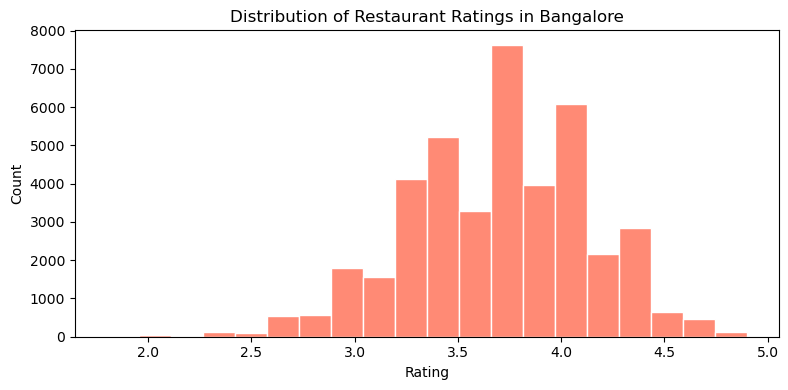

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['rate'].dropna(),bins=20,color='tomato',edgecolor='white')
plt.title("Distribution of Restaurant Ratings in Bangalore")
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/rating_distribution.png',dpi=150)
plt.show()